## Descriptive Statistics on HH-Income & Expenditure

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
incomedf=pd.read_csv(r"C:\Users\sande\Downloads\Inc_Exp_Data - Copy.csv")
incomedf.head(5)

,Mthly_HH_Income,Mthly_HH_Expense,No_of_Fly_Members,Emi_or_Rent_Amt,Annual_HH_Income,Highest_Qualified_Member,No_of_Earning_Members
0,5000,8000,3,2000,64200,Under-Graduate,1
1,6000,7000,2,3000,79920,Illiterate,1
2,10000,4500,2,0,112800,Under-Graduate,1
3,10000,2000,1,0,97200,Illiterate,1
4,12500,12000,2,3000,147000,Graduate,1


### Analyze the data

In [4]:
incomedf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Mthly_HH_Income           50 non-null     int64 
 1   Mthly_HH_Expense          50 non-null     int64 
 2   No_of_Fly_Members         50 non-null     int64 
 3   Emi_or_Rent_Amt           50 non-null     int64 
 4   Annual_HH_Income          50 non-null     int64 
 5   Highest_Qualified_Member  50 non-null     object
 6   No_of_Earning_Members     50 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 2.9+ KB


In [5]:
incomedf.shape

(50, 7)

In [6]:
incomedf.describe()

,Mthly_HH_Income,Mthly_HH_Expense,No_of_Fly_Members,Emi_or_Rent_Amt,Annual_HH_Income,No_of_Earning_Members
count,50.000000,50.000000,50.000000,50.000000,5.000000e+01,50.000000
mean,41558.000000,18818.000000,4.060000,3060.000000,4.900190e+05,1.460000
std,26097.908979,12090.216824,1.517382,6241.434948,3.201358e+05,0.734291
min,5000.000000,2000.000000,1.000000,0.000000,6.420000e+04,1.000000
25%,23550.000000,10000.000000,3.000000,0.000000,2.587500e+05,1.000000
50%,35000.000000,15500.000000,4.000000,0.000000,4.474200e+05,1.000000
75%,50375.000000,25000.000000,5.000000,3500.000000,5.947200e+05,2.000000
max,100000.000000,50000.000000,7.000000,35000.000000,1.404000e+06,4.000000


In [7]:
# This transposes the table — switches rows and columns
incomedf.describe().T

,count,mean,std,min,25%,50%,75%,max
Mthly_HH_Income,50.0,41558.00,26097.908979,5000.0,23550.0,35000.0,50375.0,100000.0
Mthly_HH_Expense,50.0,18818.00,12090.216824,2000.0,10000.0,15500.0,25000.0,50000.0
No_of_Fly_Members,50.0,4.06,1.517382,1.0,3.0,4.0,5.0,7.0
Emi_or_Rent_Amt,50.0,3060.00,6241.434948,0.0,0.0,0.0,3500.0,35000.0
Annual_HH_Income,50.0,490019.04,320135.792123,64200.0,258750.0,447420.0,594720.0,1404000.0
No_of_Earning_Members,50.0,1.46,0.734291,1.0,1.0,1.0,2.0,4.0


In [8]:
incomedf.isnull().sum()

Mthly_HH_Income             0
Mthly_HH_Expense            0
No_of_Fly_Members           0
Emi_or_Rent_Amt             0
Annual_HH_Income            0
Highest_Qualified_Member    0
No_of_Earning_Members       0
dtype: int64

In [9]:
incomedf.isna().any()

Mthly_HH_Income             False
Mthly_HH_Expense            False
No_of_Fly_Members           False
Emi_or_Rent_Amt             False
Annual_HH_Income            False
Highest_Qualified_Member    False
No_of_Earning_Members       False
dtype: bool

In [10]:
incomedf.duplicated().sum()

0

## Q. What is the Mean Expense of a Household ?

In [11]:
incomedf["Mthly_HH_Expense"].mean()

18818.0

## Q. What is the Median Expense of a Household ?

In [12]:
incomedf["Mthly_HH_Expense"].median()

15500.0

## Q. What is the Monthly Expense for most of the Households?(Mode)

In [13]:
incomedf["Mthly_HH_Expense"].mode()

0    25000
Name: Mthly_HH_Expense, dtype: int64

In [14]:
temp = pd.crosstab(index=incomedf["Mthly_HH_Expense"],columns="Count")
temp

col_0,Count
Mthly_HH_Expense,
2000,1
4500,1
5000,1
6600,1
7000,1
8000,3
9000,3
10000,5
10500,1


In [15]:
temp = pd.crosstab(index=incomedf["Mthly_HH_Expense"],columns="Count")
temp.reset_index(inplace=True)
temp[temp["Count"] == incomedf.Mthly_HH_Expense.value_counts().max()]

col_0,Mthly_HH_Expense,Count
18,25000,8


## Q. Plot the Histogram to count the Highest qualified member

<Axes: title={'center': 'Highest Qualified Member'}, xlabel='Highest_Qualified_Member'>

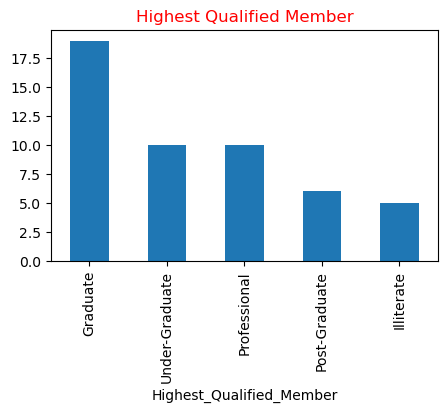

In [71]:
plt.figure(figsize=(5,3))
plt.title("Highest Qualified Member",c="red")
incomedf["Highest_Qualified_Member"].value_counts().plot(kind="bar")

## Q. Calculate IQR( Difference between 75% and 25% quartile )

In [17]:
q1=np.quantile(incomedf["Mthly_HH_Expense"],0.25)
q3=np.quantile(incomedf["Mthly_HH_Expense"],0.75)
IQR=q3-q1
print("Inter Quartile Range is",IQR)

Inter Quartile Range is 15000.0


## Q. Calculate Standard Deviation for first 4 columns.

In [30]:
pd.DataFrame(incomedf.iloc[:, :5].std().to_frame()).T

,Mthly_HH_Income,Mthly_HH_Expense,No_of_Fly_Members,Emi_or_Rent_Amt,Annual_HH_Income
0,26097.908979,12090.216824,1.517382,6241.434948,320135.792123


## Q. Calculate Variance for first 3 columns.

In [34]:
pd.DataFrame(incomedf.iloc[:,:4].var().to_frame()).T

,Mthly_HH_Income,Mthly_HH_Expense,No_of_Fly_Members,Emi_or_Rent_Amt
0,6.811009e+08,1.461733e+08,2.302449,3.895551e+07


In [35]:
incomedf.columns

Index(['Mthly_HH_Income', 'Mthly_HH_Expense', 'No_of_Fly_Members',
       'Emi_or_Rent_Amt', 'Annual_HH_Income', 'Highest_Qualified_Member',
       'No_of_Earning_Members'],
      dtype='object')

## Q. Calculate the count of Highest qualified member.

In [58]:
pd.DataFrame(incomedf["Highest_Qualified_Member"].value_counts().to_frame()).T

Highest_Qualified_Member,Graduate,Under-Graduate,Professional,Post-Graduate,Illiterate
count,19,10,10,6,5


## Q. Plot the Histogram to count the No_of_Earning_Members

<Axes: title={'center': 'No_of_Earning_Members'}, xlabel='No_of_Earning_Members'>

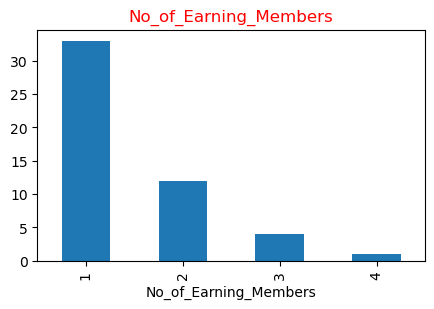

In [70]:
plt.figure(figsize=(5,3))
plt.title("No_of_Earning_Members",c="red")
incomedf['No_of_Earning_Members'].value_counts().plot(kind="bar")

#### Q. Suppose you have option to invest in Stock A or Stock B. The stocks • have different expected returns and standard deviations. The expected return of Stock A is 15% and Stock B is 10%. Standard Deviation of the returns of these stocks is 10% and 5% respectively.
#### Which is better investment ?

In [1]:
#Here we need to calculate the coeff of variation

CV_SA=10/15
CV_SB=5/10
if CV_SA > CV_SB:
    print("Stock B is Better Investment")
else:
    print("Stock A is Better Investment")

Stock B is Better Investment
